In [33]:
import seaborn as sns
import pandas as pd
import numpy as np
dat_xgb = pd.read_csv('ablation_xgboost.csv')
dat_xgb = dat_xgb.sort_values(by = ['disturbance_level', 'tree_size', 'v', 'epochs']).reset_index(drop=True)
# Create group indices: 0 for rows 0-2, 1 for 3-5, etc.
group_index = dat_xgb.index // 3

# Group by the group index and sum, then broadcast to original rows
dat_xgb['total_rmse'] = dat_xgb.groupby(group_index)['rmse'].transform('sum')
dat_xgb = dat_xgb.sort_values(by = ['disturbance_level', 'total_rmse'])
#now, fin best parameters for each disturbance_level (we choose top 3)
optimal_params_xgboost = pd.DataFrame(columns = ['disturbance_level', 'tree_size', 'v', 'epochs'])
for disturbance_level in np.unique(dat_xgb['disturbance_level']):
    data_dist = dat_xgb[dat_xgb['disturbance_level'] == disturbance_level]
    best_params = data_dist[['disturbance_level', 'tree_size', 'v', 'epochs']].iloc[[0, 3, 6]]
    optimal_params_xgboost = pd.concat((optimal_params_xgboost, best_params))

optimal_params_xgboost.to_csv('optimal_params_xgboost.csv')

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29832\1849516898.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_params_xgboost = pd.concat((optimal_params_xgboost, best_params))


In [34]:

dat_abl = pd.read_csv('ablation_transfer.csv')
dat_abl = dat_abl.sort_values(by = ['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs']).reset_index(drop=True)
# Create group indices: 0 for rows 0-2, 1 for 3-5, etc.
group_index = dat_abl.index // 3

# Group by the group index and sum, then broadcast to original rows
dat_abl['total_rmse'] = dat_abl.groupby(group_index)['rmse'].transform('sum')
dat_abl = dat_abl.sort_values(by = ['disturbance_level', 'total_rmse'])
#now, fin best parameters for each disturbance_level (we choose top 3)
optimal_params_transfer = pd.DataFrame(columns = ['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs'])
for disturbance_level in np.unique(dat_abl['disturbance_level']):
    data_dist = dat_abl[dat_abl['disturbance_level'] == disturbance_level]
    best_params = data_dist[['disturbance_level', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs']].iloc[[0, 3, 6]]
    optimal_params_transfer = pd.concat((optimal_params_transfer, best_params))

optimal_params_transfer.to_csv('optimal_params_transfer.csv')

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_29832\220433695.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_params_transfer = pd.concat((optimal_params_transfer, best_params))


In [35]:
#visualize optimal simulations
simulation_xgb = pd.read_csv('optimal_params_simulations_xgboost.csv')
simulation_xgb['method'] = 'xgboost'
simulation_transfer = pd.read_csv('optimal_params_simulations_transfer.csv')
simulation_transfer['method'] = 'transfertreeboost'
combined_data = pd.concat((simulation_xgb, simulation_transfer))

<Axes: xlabel='disturbance_level', ylabel='mae'>

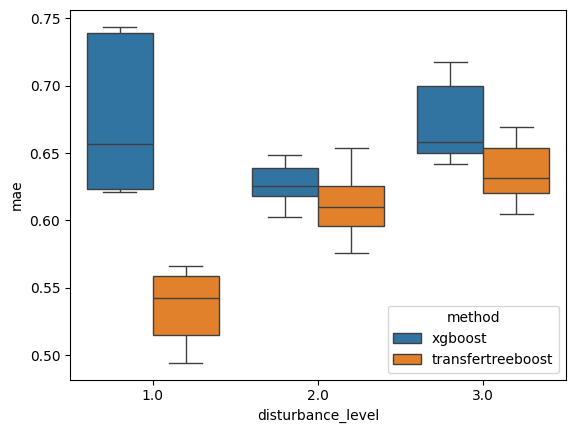

In [37]:
sns.boxplot(data = combined_data, x = 'disturbance_level', y = 'mae', hue = 'method')